In [1]:
library(tidyverse)
library(knitr)
library(scales)
library(patchwork)
library(corrplot)
library(broom)
library(AER)
library(modelr)
library(ISLR)
library(dplyr)
install.packages("arm")
library(arm)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


corrplot 0.92 loaded

Loading required package: car

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some


Loading required package: lmtest

Loading required package

In [55]:
data <- read_csv("Toronto_apartment_rentals_2018.csv")

Rows: 1124 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Address, Price
dbl (5): Bedroom, Bathroom, Den, Lat, Long

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [67]:
data <- read_csv("Toronto_apartment_rentals_2018.csv") %>%
  # Removing duplicate rows
  distinct() %>%
  # Removing unnecessary columns
  dplyr::select(-c(Address, Lat, Long)) %>%
  # Making the column names lowercase
  rename_with(tolower) %>%
  # Converting price to a number
  mutate(price = parse_number(price)) %>%
  # Removing outliers
  filter(price < 6000, price > 100) %>%
mutate(high_price = if_else(price > mean(price), 1, 0))

Rows: 1124 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Address, Price
dbl (5): Bedroom, Bathroom, Den, Lat, Long

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [68]:
data <- data %>%
  mutate(high_price = if_else(price > mean(price), 1, 0))

In [79]:
sort(data$bedroom)

[1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [38] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [75] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[112] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[149] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[186] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[223] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[260] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[297] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[334] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[371] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[408] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[445] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[482] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[519] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2
[556] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[593] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[630] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[667] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[704] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[741] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3
[778] 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3

In [70]:
nrow(data)
head(data)

[1] 807

bedroom,bathroom,den,price,high_price
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,2,0,2450,1
1,1,1,2150,0
1,1,0,1950,0
2,2,0,2900,1
1,1,0,1800,0
1,1,0,1729,0


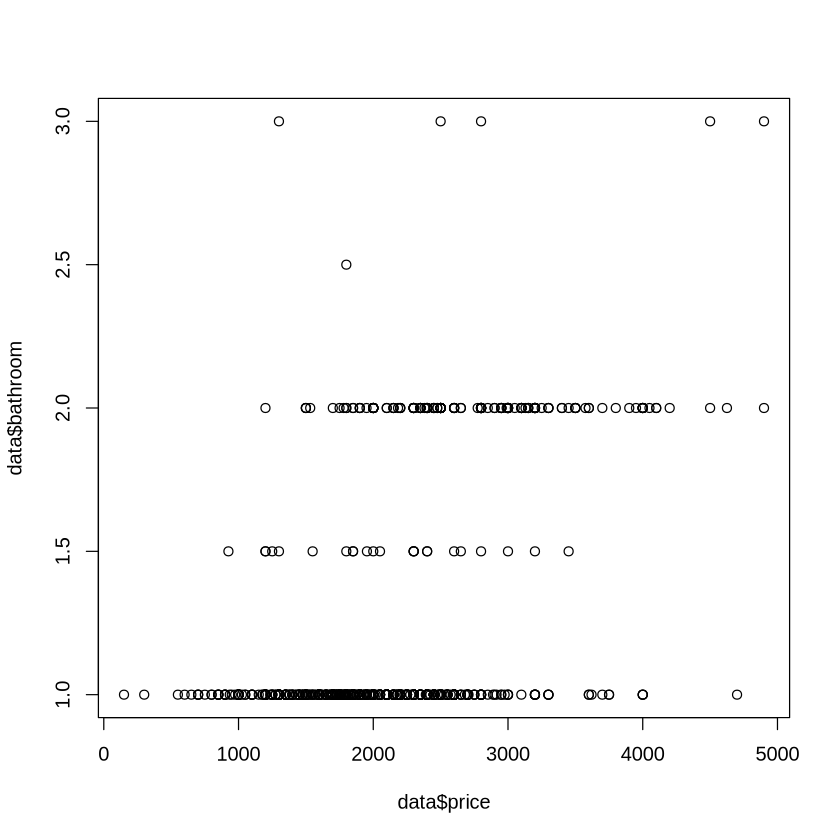

In [71]:
plot(data$price, data$bathroom)

In [72]:
linear_add <- lm(price ~ bedroom + bathroom, data = data)

linear_add_results <- 
   tidy(linear_add, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
linear_add_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1172.76,66.25,17.70,0,1042.72,1302.80
bedroom,187.90,48.35,3.89,0,93.00,282.80
bathroom,592.21,63.16,9.38,0,468.23,716.19


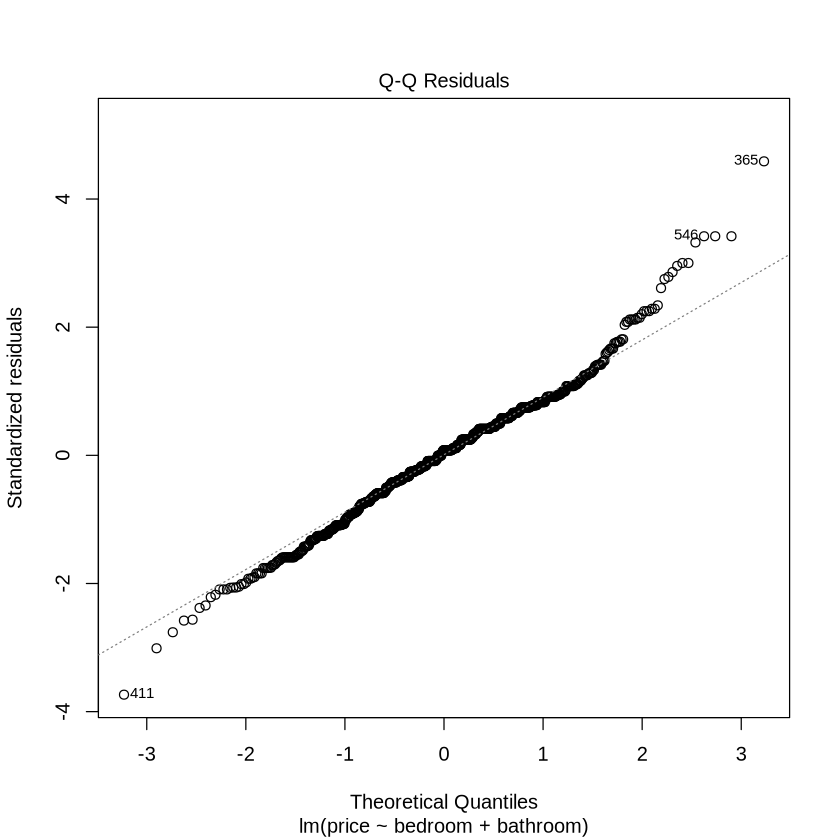

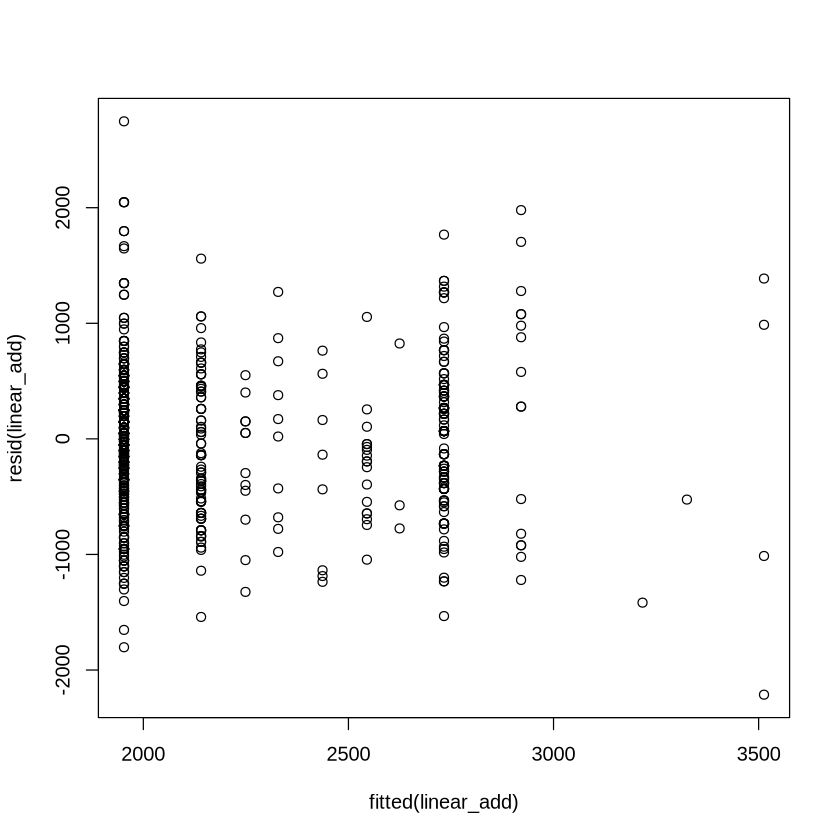

In [73]:
plot(linear_add, 2)
plot(fitted(linear_add), resid(linear_add))

In [74]:
linear_mult <- lm(price ~ bedroom * bathroom, data = data)

linear_mult_results <- 
   tidy(linear_mult, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
linear_mult_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1496.02,210.86,7.09,0.00,1082.12,1909.93
bedroom,0.95,125.45,0.01,0.99,-245.30,247.21
bathroom,318.44,180.91,1.76,0.08,-36.68,673.56
bedroom:bathroom,146.84,90.94,1.61,0.11,-31.67,325.35


**Not statistically significant. Also you can just tell its wrong, like why is the estimate for bedroom negative come on**

In [86]:
logistic_add <- glm(high_price ~ bedroom + bathroom, data = data, family = 'binomial')

logistic_add_results <- 
   tidy(logistic_add, conf.int = TRUE, conf.level = 0.95, exponentiate = TRUE) %>%
   mutate_if(is.numeric, round, 2)
logistic_add_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.09,0.26,-9.33,0.0,0.05,0.15
bedroom,1.24,0.17,1.27,0.2,0.89,1.73
bathroom,5.25,0.24,6.81,0.0,3.29,8.55


In [87]:
logistic_mult <- glm(high_price ~ bedroom * bathroom, data = data, family = 'binomial')

logistic_mult_results <- 
   tidy(logistic_mult, conf.int = TRUE, conf.level = 0.95, exponentiate = TRUE) %>%
   mutate_if(is.numeric, round, 2)
logistic_mult_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),0.03,0.88,-3.83,0.00,0.01,0.20
bedroom,2.14,0.50,1.50,0.13,0.77,5.60
bathroom,12.05,0.78,3.19,0.00,2.61,55.92
bedroom:bathroom,0.64,0.39,-1.14,0.25,0.30,1.41


In [88]:
logistic_add_disp <- glm(high_price ~ bedroom + bathroom, data = data, family = 'quasibinomial')
summary(logistic_add_disp)


Call:
glm(formula = high_price ~ bedroom + bathroom, family = "quasibinomial", 
    data = data)

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -2.4096     0.2615  -9.216  < 2e-16 ***
bedroom       0.2164     0.1726   1.254     0.21    
bathroom      1.6578     0.2463   6.730 3.23e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for quasibinomial family taken to be 1.024747)

    Null deviance: 1116.4  on 806  degrees of freedom
Residual deviance: 1013.6  on 804  degrees of freedom
AIC: NA

Number of Fisher Scoring iterations: 4


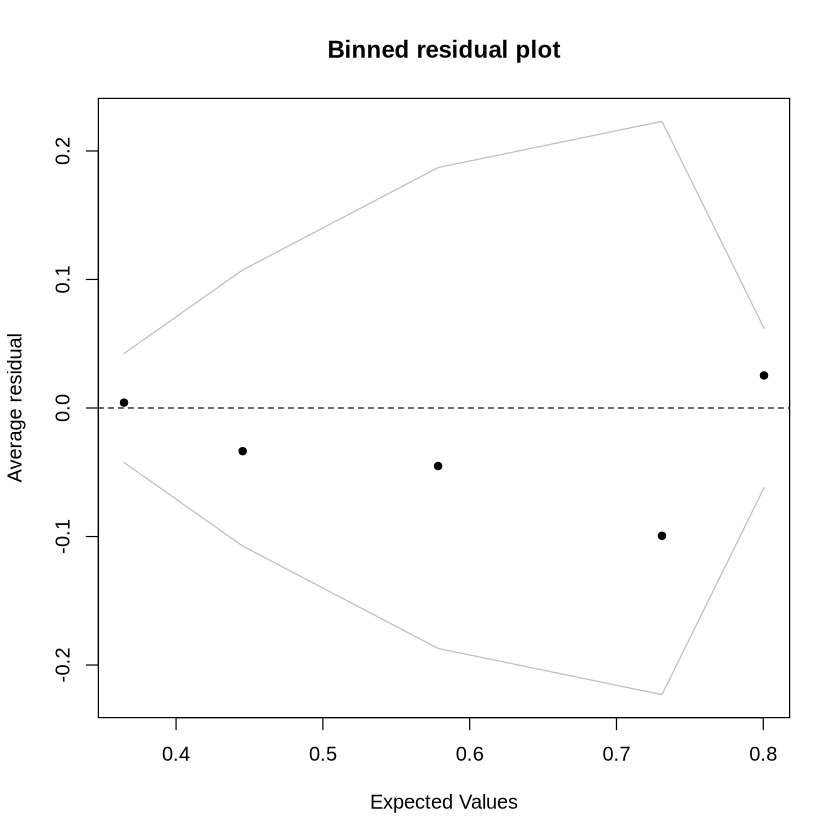

In [77]:
binnedplot(fitted(logistic_mult), resid(logistic_mult))

In [15]:
data <-
    data %>% 
    add_predictions(linear, var = 'linear_predictions')

linear_plot <- 
    data %>%
    ggplot(aes(x = bedroom, y = price, color = bathroom)) +
    geom_point() +
    geom_line(aes(y = linear_predictions), linewidth = 1) +
    labs(title = 'Reading score vs income by grade range without interactions',
         x = 'Number of bedrooms',
         y = 'Price') +
    theme(text = element_text(size = 16.5),
          plot.title = element_text(face = "bold"),
          axis.title = element_text(face = "bold"),
          legend.title = element_text(face = "bold")) +
    labs(color = "Number of bathrooms")

# your code here
# fail() # No Answer - remove if you provide an answer

# linear_plot

ERROR: Error: object 'linear' not found
